## Initializing polymer systems using a DPD potential
This notebook walks through the PhantomWalk functions for packing linear polymers in a box. The polymers are first placed in a cubic box using a random walk. Then a short HOOMD simulation is run with the soft force potential of Dissipative Particle Dynamics. The simulation ends when the pair energy from the DPD potential reaches a stable state, as checked with an autocorrelation function.

In [1]:
import sys
import os
sys.path.append('../lib/')
import create_system_dpd
from create_system_dpd import create_polymer_system_dpd
import matplotlib
import numpy as np  
import gsd, gsd.hoomd 
from cmeutils.sampling import is_equilibrated
import hoomd 
import time
import freud
import matplotlib_inline
import matplotlib.pyplot as plt
%matplotlib inline
matplotlib.style.use("ggplot")
matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
import warnings
warnings.filterwarnings("ignore")
matplotlib_inline.backend_inline.set_matplotlib_formats("svg")

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



In [34]:
num_pol=100
num_mon=100
N = num_pol*num_mon
density=0.8
s = create_polymer_system_dpd(A=1000,gamma=800,k=20000,num_pol=num_pol,num_mon=num_mon,energy=True,density=density,write=True,r_cut=1.13)
print(f"Finished in time = {s:.2f}s")

10000

Running with A=1000, gamma=800, k=20000, num_pol=100, num_mon=100
Total build time:  0.0015896080003585666
4333.8
Total build and simulation time: 21.090176144003635
Finished in time = 21.09s


In [39]:
def calculate_pair_energy(A,r,r_cut,N,M,density):
    '''
    Calculate the minimum energy for the conservative force to reach at the given radius.
    energy for each pair in the system
    '''
    density_scaling = (1.41-density)/((1.41+density)/2)
    constant = (1/2)*A*r_cut
    pe = (A*(r**2))/(2*r_cut) - (A*r) + constant
    pair_energy = 10*pe*(N*M)*density_scaling/2

    return pair_energy
    
U = calculate_pair_energy(A=1000,r_cut=1.13,r=1.1,N=num_pol,M=num_mon,density=density)
print(U)

10991.87122092423


## Visualize the Energy

Total steps 125100


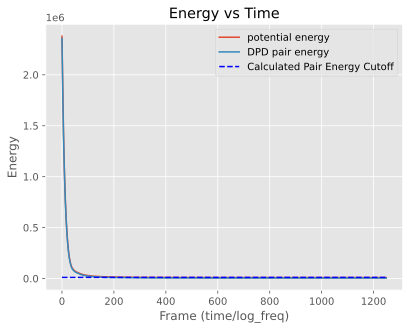

In [40]:
log = np.genfromtxt("log.txt", names=True)
pe = log["mdcomputeThermodynamicQuantitiespotential_energy"]
bonds = log["mdbondHarmonicenergy"]
pairs = log["mdpairDPDenergy"]
print("Total steps",len(pe)*100+100)
cut = 0
short= None
x_values = range(cut, len(pe[:short]))
plt.plot(x_values,pe[cut:short], label="potential energy")
plt.plot(x_values,pairs[cut:short], label="DPD pair energy")
plt.hlines(U,xmin=cut,xmax=len(pairs[:short]),color="blue",linestyle="--",label="Calculated Pair Energy Cutoff")
plt.title("Energy vs Time")
plt.xlabel("Frame (time/log_freq)")
plt.ylabel("Energy")

plt.legend()
#plt.savefig("10-10mers-energy-cut")

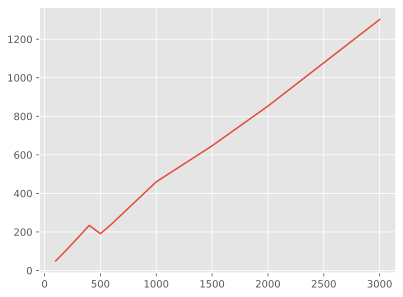

In [6]:
x= [100,200,400,500,600,1000,1500,2000,3000]
y=[50,109,234,190.8,241,460,647,853,1302]
plt.plot(x,y)